<a href="https://colab.research.google.com/github/masterAristocats/Trabalho-Processamento-de-Sinais-I-7/blob/main/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def get_window_manual(M, window_type):
    """Gera funções-janela analiticamente."""
    n = np.arange(M + 1)
    if window_type == 'retangular':
        return np.ones(M + 1)
    elif window_type in ['triangular', 'bartlett']:
        return 1.0 - np.abs(2 * n - M) / M
    elif window_type == 'hamming':
        return 0.54 - 0.46 * np.cos(2 * np.pi * n / M)
    elif window_type == 'hann':
        return 0.5 - 0.5 * np.cos(2 * np.pi * n / M)
    elif window_type == 'blackman':
        return 0.42 - 0.5 * np.cos(2 * np.pi * n / M) + 0.08 * np.cos(4 * np.pi * n / M)
    return np.ones(M + 1)

def manual_fir_design(M, filter_type, fc1, fc2=None, fs=20000, window_type='retangular'):
    """Calcula os coeficientes do filtro FIR (Resposta ao Impulso) do zero."""
    n = np.arange(M + 1)
    alpha = M / 2

    wc1 = 2 * np.pi * (fc1 / fs)
    wc2 = 2 * np.pi * (fc2 / fs) if fc2 else 0

    # Prevenção de divisão por zero no ponto de simetria
    eps = 1e-10
    n_safe = np.where(n == alpha, n + eps, n)

    if filter_type == 'passa_baixas':
        h_ideal = np.sin(wc1 * (n_safe - alpha)) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = wc1 / np.pi

    elif filter_type == 'passa_altas':
        h_ideal = -np.sin(wc1 * (n_safe - alpha)) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = 1.0 - (wc1 / np.pi)

    elif filter_type == 'passa_faixas':
        h_ideal = (np.sin(wc2 * (n_safe - alpha)) - np.sin(wc1 * (n_safe - alpha))) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = (wc2 - wc1) / np.pi

    elif filter_type == 'rejeita_faixas':
        h_ideal = (np.sin(wc1 * (n_safe - alpha)) - np.sin(wc2 * (n_safe - alpha))) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = 1.0 - ((wc2 - wc1) / np.pi)

    w = get_window_manual(M, window_type)
    return h_ideal * w

def plot_fir_analysis(filter_type, fc1, fc2=None, title=""):
    """Função para gerar e plotar as análises exigidas de forma organizada."""
    fs = 20000
    orders = [20, 50, 100]
    windows = ['retangular', 'triangular', 'hamming', 'hann', 'blackman']

    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(title, fontsize=16)

    # 1. Resposta ao Impulso (M=50, todas as janelas)
    M_fixed = 50
    for win in windows:
        h = manual_fir_design(M_fixed, filter_type, fc1, fc2, fs, win)
        axes[0, 0].plot(h, label=win.capitalize(), marker='.', alpha=0.7)
    axes[0, 0].set_title(f"Resposta ao Impulso (M={M_fixed})")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # 2. Resposta em Frequência (Comparando Janelas, M=50)
    for win in windows:
        h = manual_fir_design(M_fixed, filter_type, fc1, fc2, fs, win)
        w, H = signal.freqz(h, worN=8000, fs=fs)
        axes[0, 1].plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=win.capitalize())
    axes[0, 1].set_title(f"Módulo em dB - Diferentes Janelas (M={M_fixed})")
    axes[0, 1].set_ylim([-80, 5])
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # 3. Resposta em Frequência (Comparando Ordens, Janela Hamming)
    win_fixed = 'hamming'
    for M in orders:
        h = manual_fir_design(M, filter_type, fc1, fc2, fs, win_fixed)
        w, H = signal.freqz(h, worN=8000, fs=fs)
        axes[1, 0].plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=f'M={M}')
    axes[1, 0].set_title(f"Módulo em dB - Diferentes Ordens (Janela: {win_fixed.capitalize()})")
    axes[1, 0].set_ylim([-80, 5])
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # 4. Fase (M=50, Hamming)
    h_phase = manual_fir_design(M_fixed, filter_type, fc1, fc2, fs, win_fixed)
    w_phase, H_phase = signal.freqz(h_phase, worN=8000, fs=fs)
    axes[1, 1].plot(w_phase, np.unwrap(np.angle(H_phase)))
    axes[1, 1].set_title(f"Resposta de Fase (M={M_fixed}, {win_fixed.capitalize()})")
    axes[1, 1].grid(True)

    # 5. Diagrama de Polos e Zeros (M=50, Hamming)
    zeros = np.roots(h_phase)
    axes[2, 0].scatter(np.real(zeros), np.imag(zeros), s=30, marker='o', edgecolors='b', facecolors='none', label='Zeros')
    axes[2, 0].scatter([0], [0], s=30, marker='x', color='r', label=f'{M_fixed} Polos')
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    axes[2, 0].add_patch(circle)
    axes[2, 0].set_aspect('equal')
    axes[2, 0].set_xlim([-1.5, 1.5])
    axes[2, 0].set_ylim([-1.5, 1.5])
    axes[2, 0].set_title(f"Polos e Zeros (M={M_fixed}, {win_fixed.capitalize()})")
    axes[2, 0].legend()
    axes[2, 0].grid(True)

    # Ocultar o último subplot vazio
    axes[2, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def get_window_manual(M, window_type):
    """Gera funções-janela analiticamente."""
    n = np.arange(M + 1)
    if window_type == 'retangular':
        return np.ones(M + 1)
    elif window_type in ['triangular', 'bartlett']:
        return 1.0 - np.abs(2 * n - M) / M
    elif window_type == 'hamming':
        return 0.54 - 0.46 * np.cos(2 * np.pi * n / M)
    elif window_type == 'hann':
        return 0.5 - 0.5 * np.cos(2 * np.pi * n / M)
    elif window_type == 'blackman':
        return 0.42 - 0.5 * np.cos(2 * np.pi * n / M) + 0.08 * np.cos(4 * np.pi * n / M)
    return np.ones(M + 1)

def manual_fir_design(M, filter_type, fc1, fc2=None, fs=20000, window_type='retangular'):
    """Calcula os coeficientes do filtro FIR (Resposta ao Impulso) do zero."""
    n = np.arange(M + 1)
    alpha = M / 2

    wc1 = 2 * np.pi * (fc1 / fs)
    wc2 = 2 * np.pi * (fc2 / fs) if fc2 else 0

    eps = 1e-10
    n_safe = np.where(n == alpha, n + eps, n)

    if filter_type == 'passa_baixas':
        h_ideal = np.sin(wc1 * (n_safe - alpha)) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = wc1 / np.pi

    elif filter_type == 'passa_altas':
        h_ideal = -np.sin(wc1 * (n_safe - alpha)) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = 1.0 - (wc1 / np.pi)

    elif filter_type == 'passa_faixas':
        h_ideal = (np.sin(wc2 * (n_safe - alpha)) - np.sin(wc1 * (n_safe - alpha))) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = (wc2 - wc1) / np.pi

    elif filter_type == 'rejeita_faixas':
        h_ideal = (np.sin(wc1 * (n_safe - alpha)) - np.sin(wc2 * (n_safe - alpha))) / (np.pi * (n_safe - alpha))
        if M % 2 == 0: h_ideal[int(alpha)] = 1.0 - ((wc2 - wc1) / np.pi)

    w = get_window_manual(M, window_type)
    return h_ideal * w

def plot_fir_analysis(filter_type, fc1, fc2=None, title=""):
    """Função para gerar e plotar as análises exigidas de forma organizada."""
    fs = 20000
    orders = [20, 50, 100]
    windows = ['retangular', 'triangular', 'hamming', 'hann', 'blackman']

    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(title, fontsize=16)

    M_fixed = 50
    for win in windows:
        h = manual_fir_design(M_fixed, filter_type, fc1, fc2, fs, win)
        axes[0, 0].plot(h, label=win.capitalize(), marker='.', alpha=0.7)
    axes[0, 0].set_title(f"Resposta ao Impulso (M={M_fixed})")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    for win in windows:
        h = manual_fir_design(M_fixed, filter_type, fc1, fc2, fs, win)
        w, H = signal.freqz(h, worN=8000, fs=fs)
        axes[0, 1].plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=win.capitalize())
    axes[0, 1].set_title(f"Módulo em dB - Diferentes Janelas (M={M_fixed})")
    axes[0, 1].set_ylim([-80, 5])
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    win_fixed = 'hamming'
    for M in orders:
        h = manual_fir_design(M, filter_type, fc1, fc2, fs, win_fixed)
        w, H = signal.freqz(h, worN=8000, fs=fs)
        axes[1, 0].plot(w, 20 * np.log10(np.abs(H) + 1e-12), label=f'M={M}')
    axes[1, 0].set_title(f"Módulo em dB - Diferentes Ordens (Janela: {win_fixed.capitalize()})")
    axes[1, 0].set_ylim([-80, 5])
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    h_phase = manual_fir_design(M_fixed, filter_type, fc1, fc2, fs, win_fixed)
    w_phase, H_phase = signal.freqz(h_phase, worN=8000, fs=fs)
    axes[1, 1].plot(w_phase, np.unwrap(np.angle(H_phase)))
    axes[1, 1].set_title(f"Resposta de Fase (M={M_fixed}, {win_fixed.capitalize()})")
    axes[1, 1].grid(True)

    zeros = np.roots(h_phase)
    axes[2, 0].scatter(np.real(zeros), np.imag(zeros), s=30, marker='o', edgecolors='b', facecolors='none', label='Zeros')
    axes[2, 0].scatter([0], [0], s=30, marker='x', color='r', label=f'{M_fixed} Polos')
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    axes[2, 0].add_patch(circle)
    axes[2, 0].set_aspect('equal')
    axes[2, 0].set_xlim([-1.5, 1.5])
    axes[2, 0].set_ylim([-1.5, 1.5])
    axes[2, 0].set_title(f"Polos e Zeros (M={M_fixed}, {win_fixed.capitalize()})")
    axes[2, 0].legend()
    axes[2, 0].grid(True)

    axes[2, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

1a

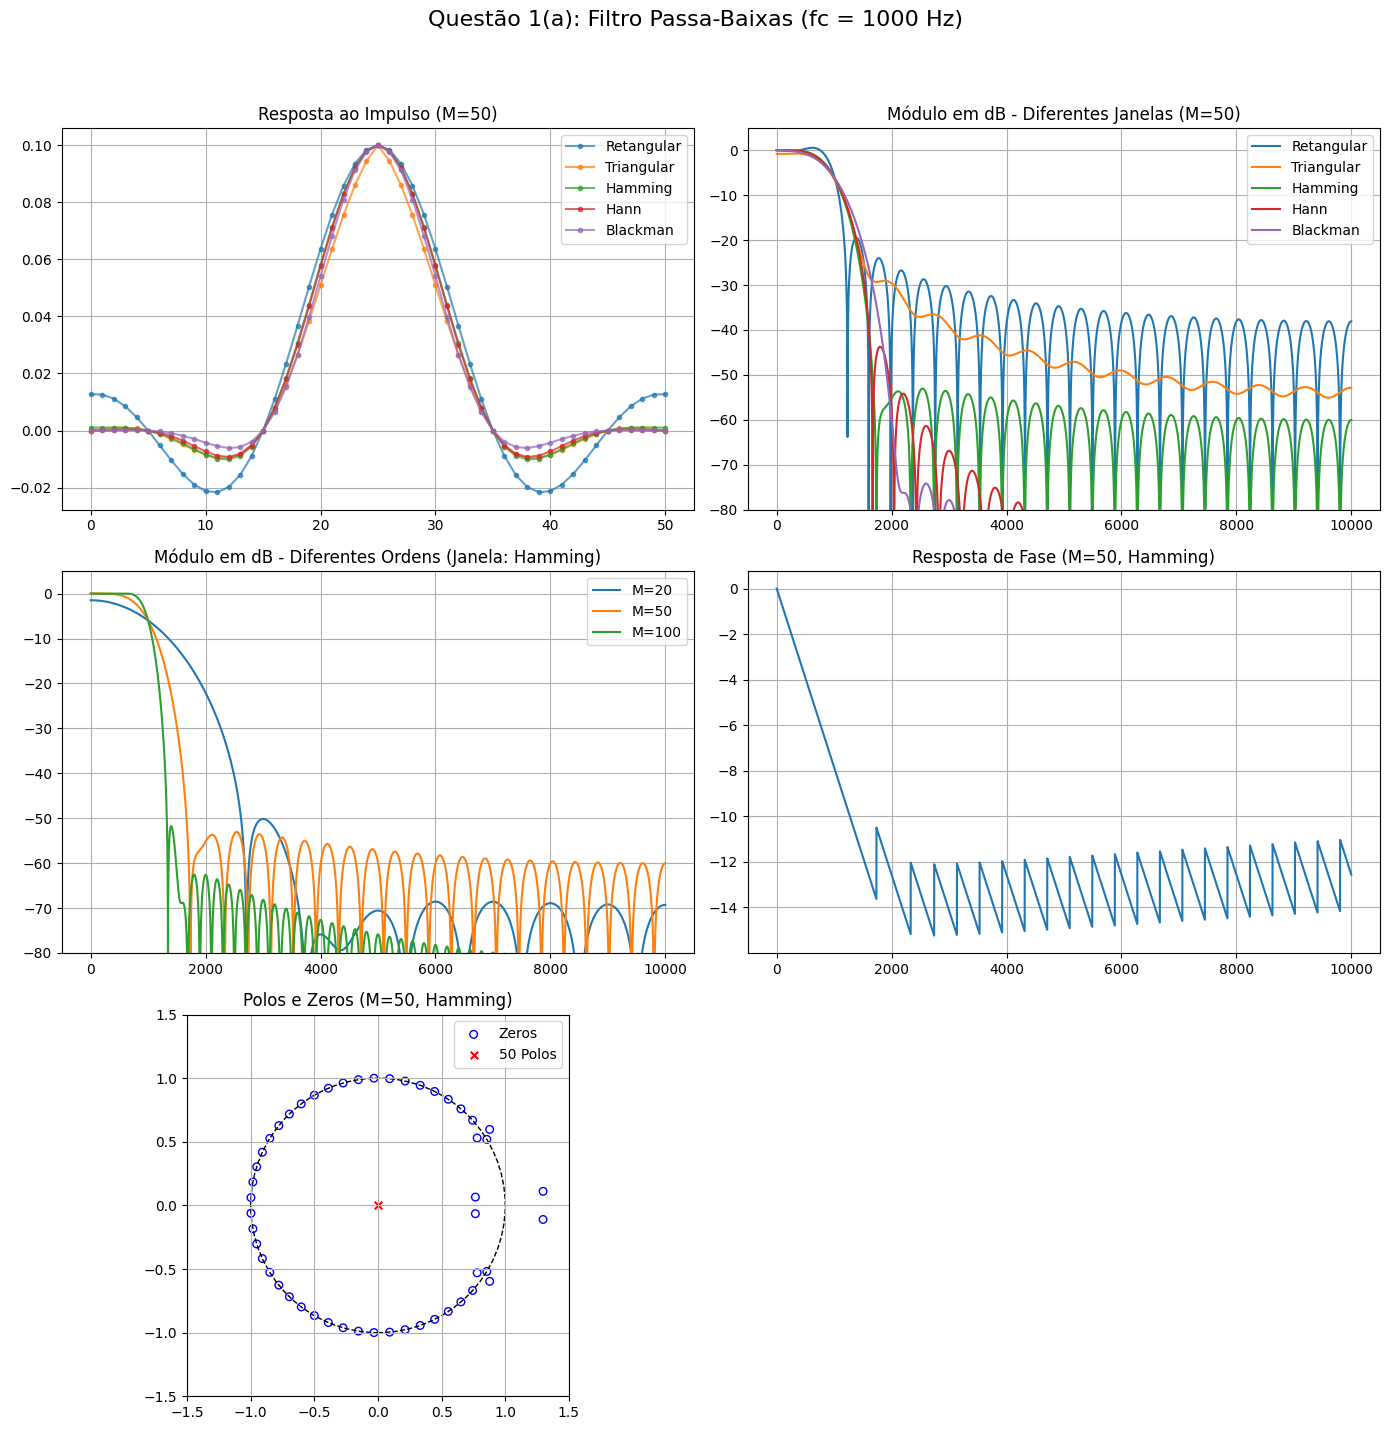

In [10]:
# Projeto 1(a): Passa-baixas com fc = 1000 Hz
plot_fir_analysis('passa_baixas', fc1=1000, title="Questão 1(a): Filtro Passa-Baixas (fc = 1000 Hz)")

Comentários - Passa-Baixas: Observa-se que o aumento da ordem $M$ (de 20 para 100) reduz drasticamente a largura da banda de transição, tornando o corte em 1000 Hz muito mais abrupto e ideal. Analisando as janelas, a Retangular apresenta a transição mais estreita, porém sofre severamente com o Fenômeno de Gibbs (oscilações elevadas na banda de passagem e rejeição). As janelas de Hamming, Hann e Blackman aumentam ligeiramente a banda de transição, mas oferecem uma atenuação muito superior na banda de rejeição. Diferente dos filtros IIR (Prática 6), o diagrama de polos e zeros demonstra que todos os polos estão travados na origem ($z=0$), provando que este filtro FIR é intrinsecamente estável e apresenta fase perfeitamente linear.

1b

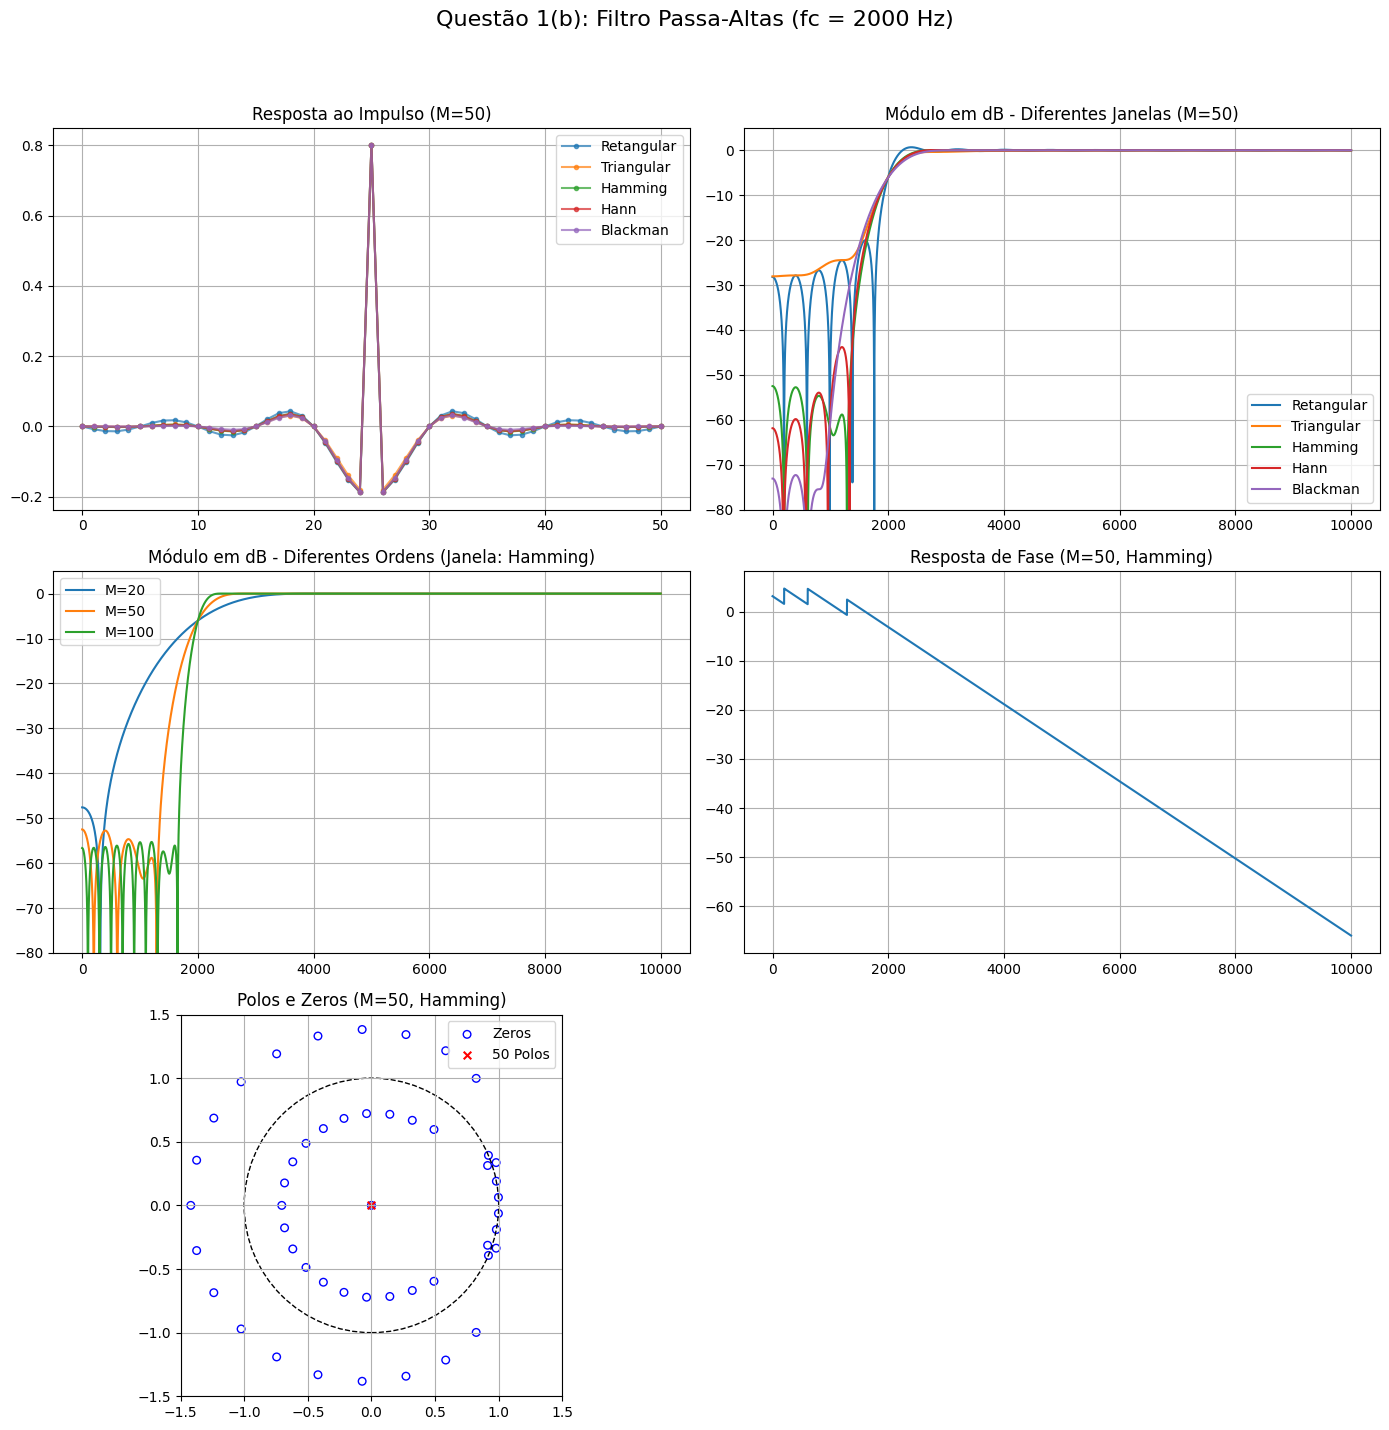

In [3]:
# Projeto 1(b): Passa-altas com fc = 2000 Hz
plot_fir_analysis('passa_altas', fc1=2000, title="Questão 1(b): Filtro Passa-Altas (fc = 2000 Hz)")

Comentários - Passa-Altas: O filtro bloqueia as frequências abaixo de 2000 Hz e permite a passagem do espectro superior até $f_s/2$. Notamos que, para projetar um filtro passa-altas FIR eficiente e sem distorção na frequência de Nyquist ($f_s/2$), a ordem $M$ deve ser preferencialmente par (neste caso, testamos 20, 50 e 100, que são adequadas). A janela de Blackman exibe a resposta mais limpa na faixa de rejeição (maior atenuação de lóbulo secundário), ideal para evitar vazamento de frequências baixas não desejadas no áudio, em troca de uma resposta ao impulso ligeiramente mais alargada no domínio do tempo.

1c

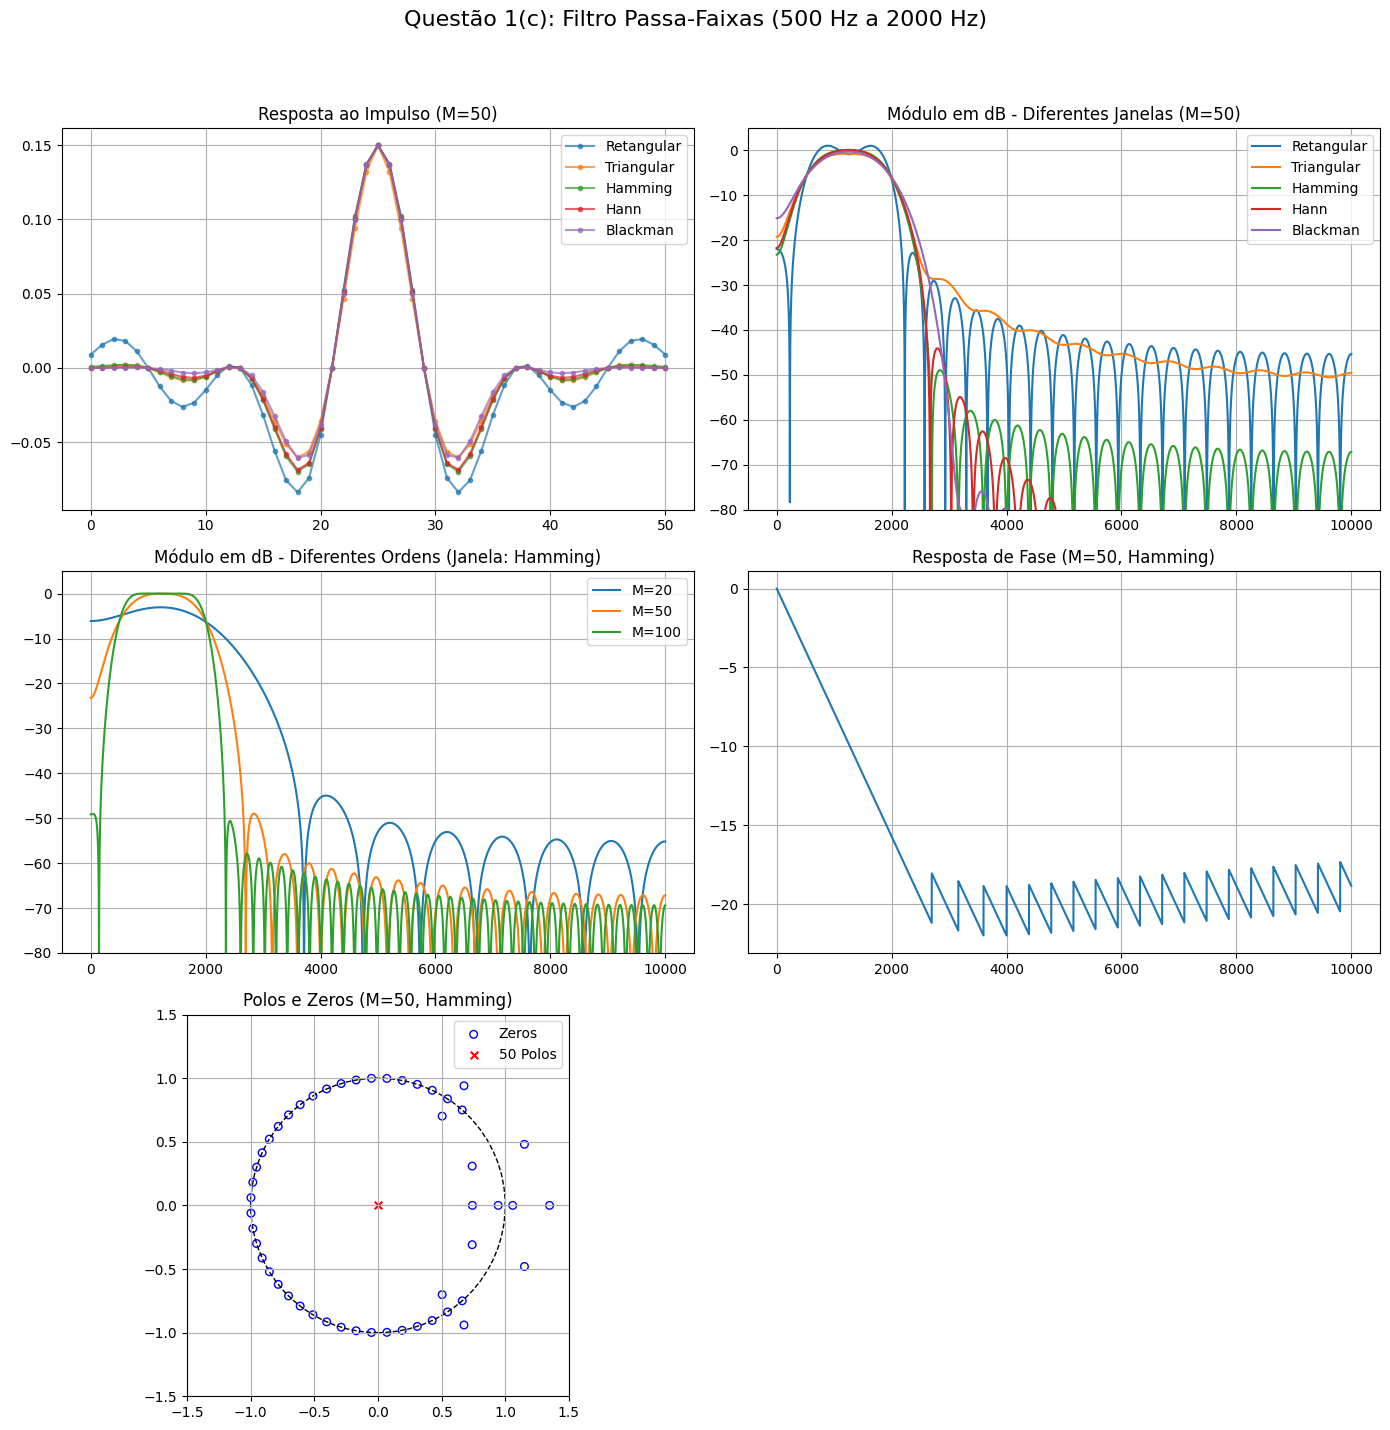

In [5]:
# Projeto 1(c): Passa-faixas com fc1 = 500 Hz e fc2 = 2000 Hz
plot_fir_analysis('passa_faixas', fc1=500, fc2=2000, title="Questão 1(c): Filtro Passa-Faixas (500 Hz a 2000 Hz)")

Comentários - Passa-Faixas: Este filtro combina o comportamento matemático de um passa-baixas e um passa-altas. Para valores baixos de $M$ (ex: $M=20$), a banda de passagem fica bastante arredondada e imprecisa, não respeitando estritamente os limites de 500 Hz e 2000 Hz devido à larga banda de transição. Ao elevar a ordem para $M=100$, as paredes da banda de passagem tornam-se retas (altamente seletivas). O uso da janela de Hamming demonstra ser um excelente compromisso (trade-off) entre uma transição íngreme e ondulações controladas (ripple reduzido) em comparação com a janela Triangular ou Retangular.

1d

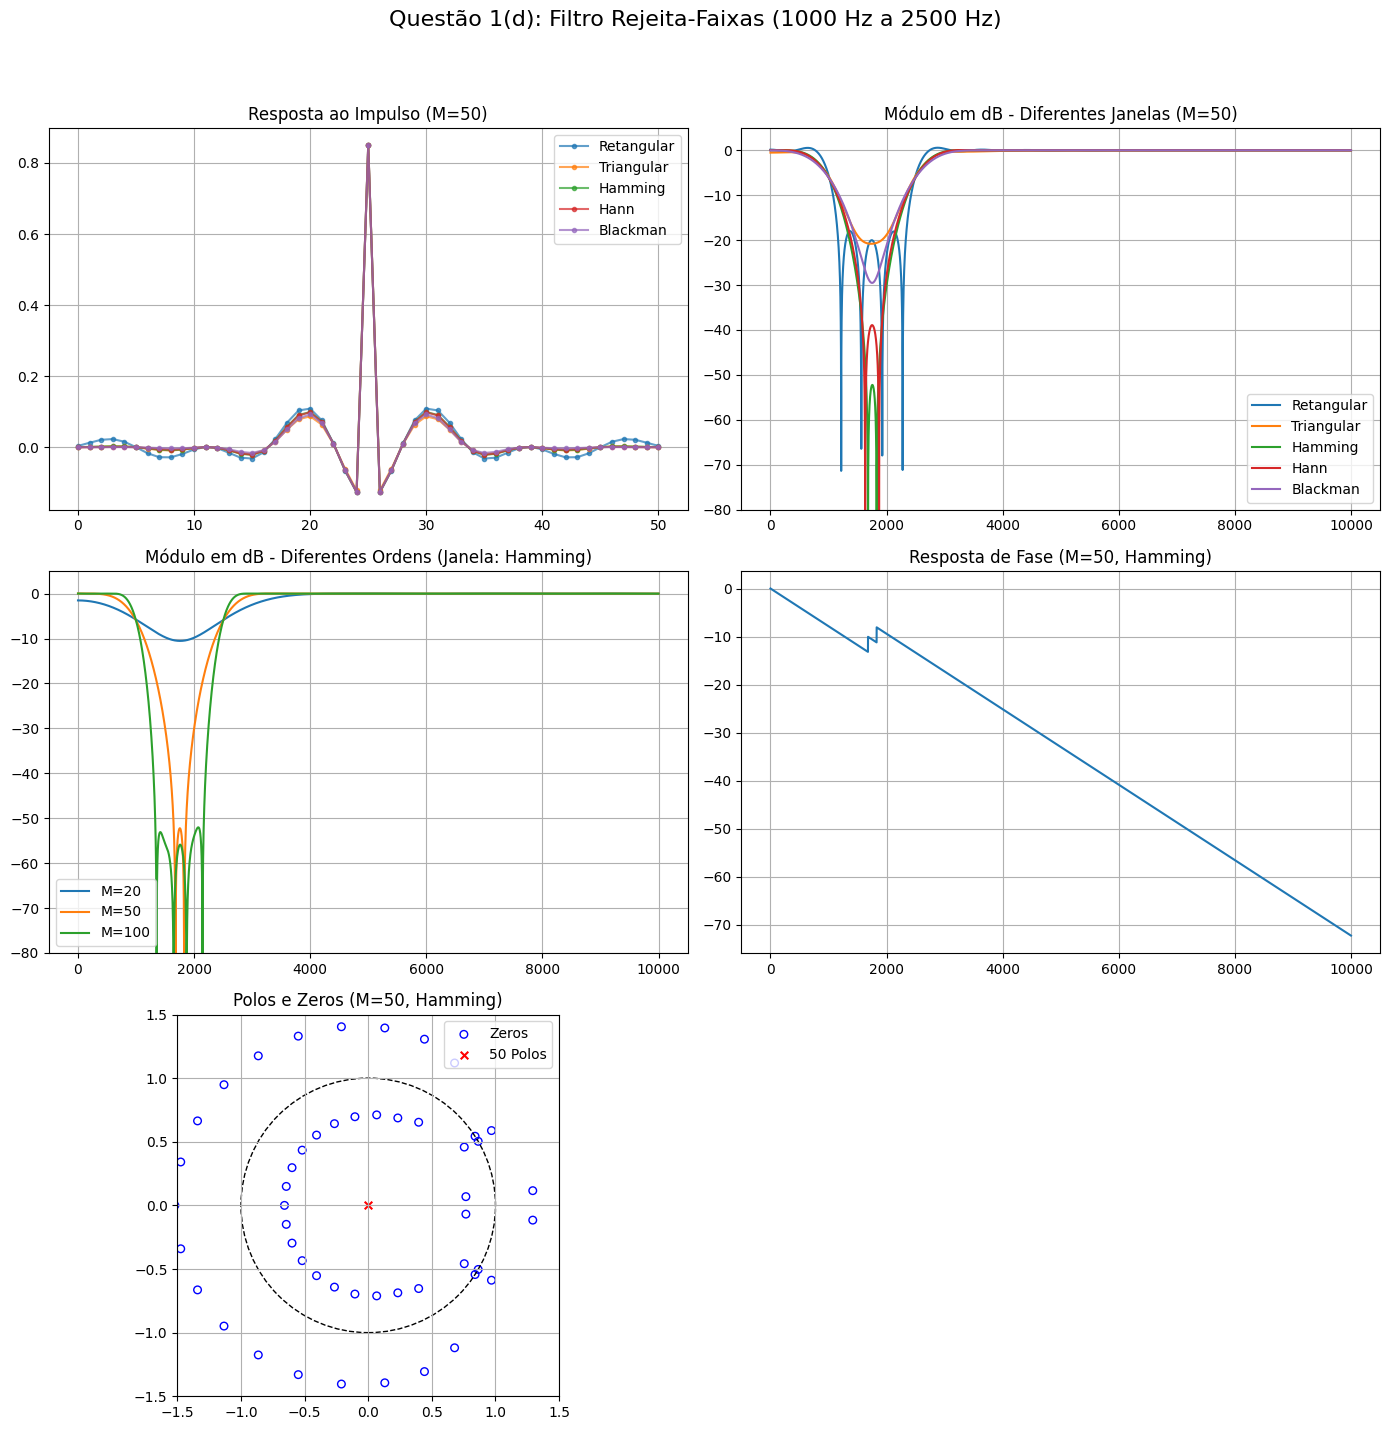

In [6]:
# Projeto 1(d): Rejeita-faixas com fc1 = 1000 Hz e fc2 = 2500 Hz
plot_fir_analysis('rejeita_faixas', fc1=1000, fc2=2500, title="Questão 1(d): Filtro Rejeita-Faixas (1000 Hz a 2500 Hz)")

Comentários - Rejeita-Faixas: O objetivo deste filtro é criar um "entalhe" (notch) largo para eliminar componentes entre 1000 e 2500 Hz. O diagrama de polos e zeros mostra os zeros distribuídos estrategicamente na região do círculo unitário correspondente a essa faixa de frequências digitais (entre $0.1\pi$ e $0.25\pi$ rad/amostra), garantindo o cancelamento espectral. Comparando com a Prática 6 (onde o Notch IIR usava apenas 1 par de polos/zeros complexos resultando num corte finíssimo), este modelo FIR transversal requer ordens consideravelmente altas ($M=100$) e uma janela suave (como Hann ou Blackman) para atingir um grau de atenuação profundo e plano na banda de rejeição, mas garante que o restante do sinal não sofra distorção de fase.

2a

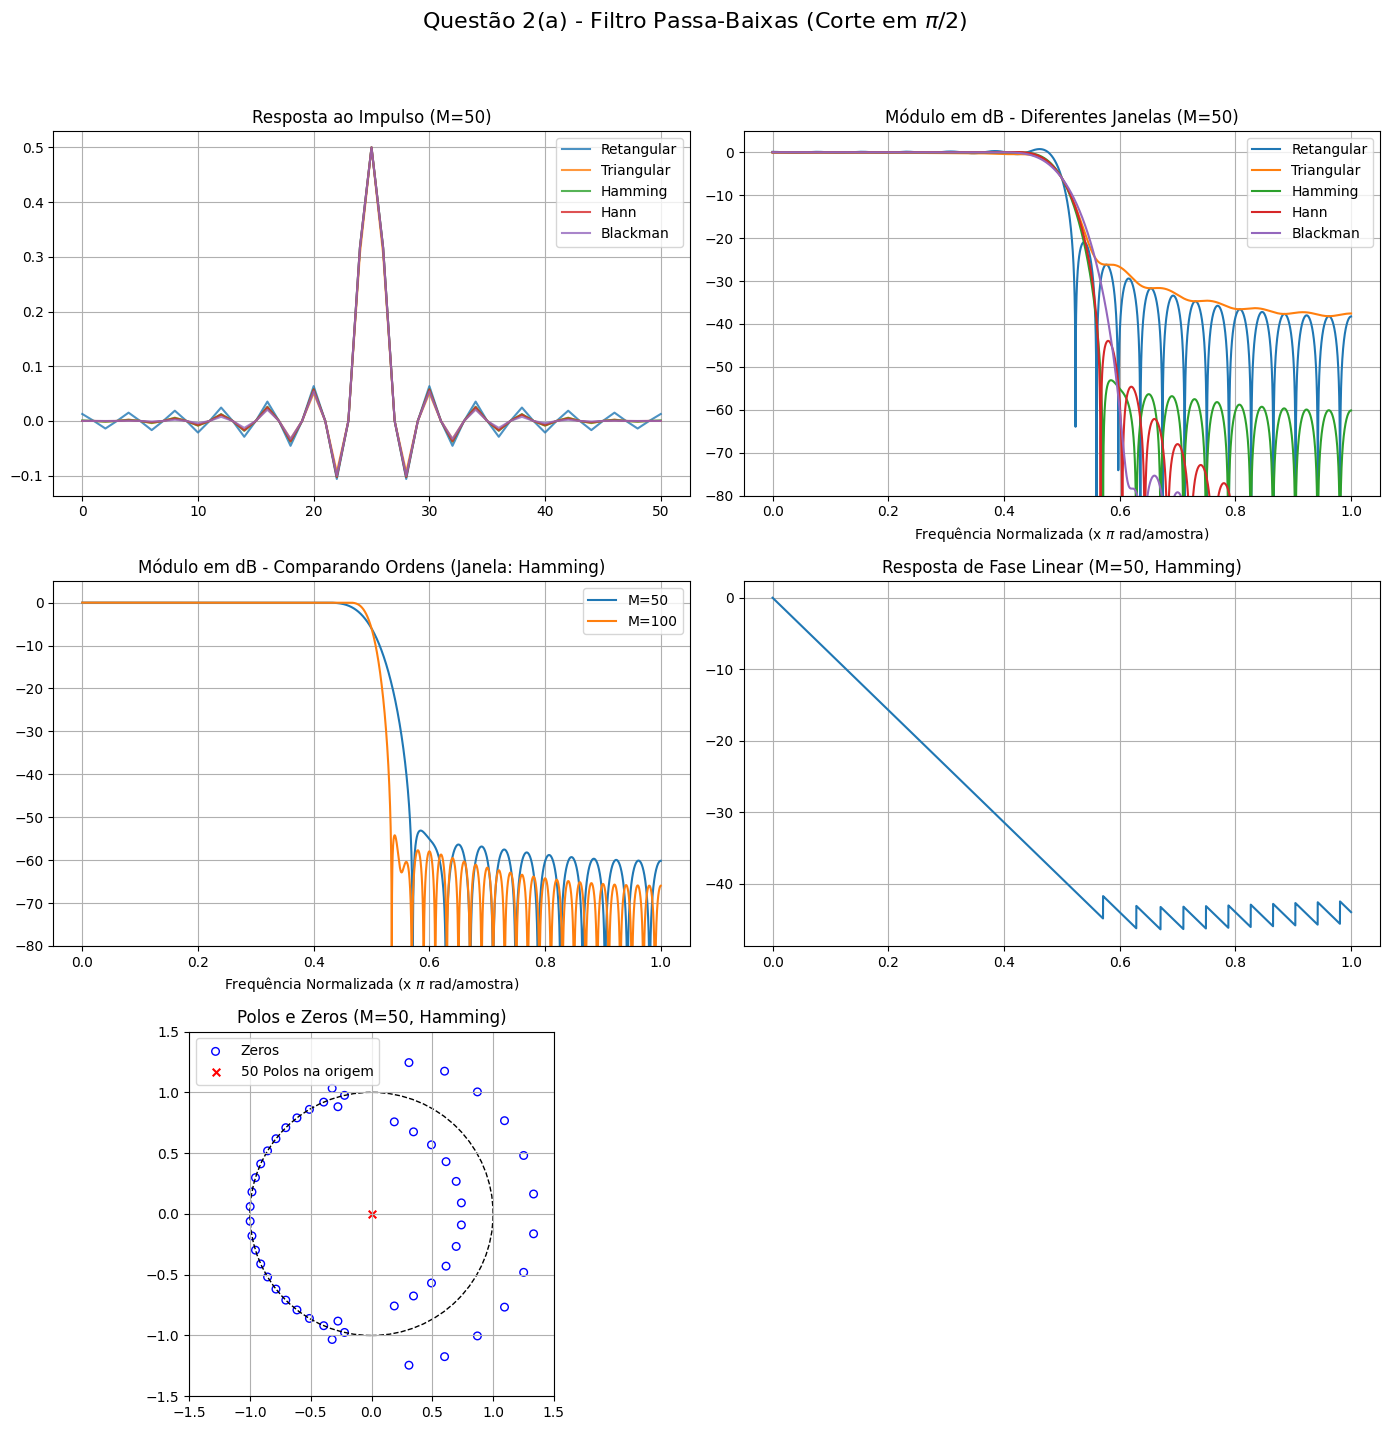

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def plot_q2_analysis(h_func, title):
    """Função genérica para plotar os requisitos da Q2 (Ordens 50 e 100)"""
    orders = [50, 100]
    windows = ['retangular', 'triangular', 'hamming', 'hann', 'blackman']

    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(title, fontsize=16)

    # 1. Resposta ao Impulso (M=50, todas as janelas)
    for win in windows:
        h = h_func(50, win)
        axes[0, 0].plot(h, label=win.capitalize(), alpha=0.8)
    axes[0, 0].set_title("Resposta ao Impulso (M=50)")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # 2. Espectro - Diferentes Janelas (M=50)
    for win in windows:
        h = h_func(50, win)
        w, H = signal.freqz(h, worN=8000)
        axes[0, 1].plot(w/np.pi, 20 * np.log10(np.abs(H) + 1e-12), label=win.capitalize())
    axes[0, 1].set_title("Módulo em dB - Diferentes Janelas (M=50)")
    # Corrigido com 'r' antes das aspas
    axes[0, 1].set_xlabel(r"Frequência Normalizada (x $\pi$ rad/amostra)")
    axes[0, 1].set_ylim([-80, 5])
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # 3. Espectro - Comparando Ordens (Janela Hamming)
    for M in orders:
        h = h_func(M, 'hamming')
        w, H = signal.freqz(h, worN=8000)
        axes[1, 0].plot(w/np.pi, 20 * np.log10(np.abs(H) + 1e-12), label=f'M={M}')
    axes[1, 0].set_title("Módulo em dB - Comparando Ordens (Janela: Hamming)")
    # Corrigido com 'r' antes das aspas
    axes[1, 0].set_xlabel(r"Frequência Normalizada (x $\pi$ rad/amostra)")
    axes[1, 0].set_ylim([-80, 5])
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # 4. Fase (M=50, Hamming)
    h_phase = h_func(50, 'hamming')
    w_phase, H_phase = signal.freqz(h_phase, worN=8000)
    axes[1, 1].plot(w_phase/np.pi, np.unwrap(np.angle(H_phase)))
    axes[1, 1].set_title("Resposta de Fase Linear (M=50, Hamming)")
    axes[1, 1].grid(True)

    # 5. Diagrama de Polos e Zeros (M=50, Hamming)
    zeros = np.roots(h_phase)
    axes[2, 0].scatter(np.real(zeros), np.imag(zeros), s=30, marker='o', edgecolors='b', facecolors='none', label='Zeros')
    axes[2, 0].scatter([0], [0], s=30, marker='x', color='r', label='50 Polos na origem')
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    axes[2, 0].add_patch(circle)
    axes[2, 0].set_aspect('equal')
    axes[2, 0].set_xlim([-1.5, 1.5])
    axes[2, 0].set_ylim([-1.5, 1.5])
    axes[2, 0].set_title("Polos e Zeros (M=50, Hamming)")
    axes[2, 0].legend()
    axes[2, 0].grid(True)

    axes[2, 1].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Resolução 2(a)
def h_ideal_2a(M, window_type):
    n = np.arange(M + 1)
    alpha = M / 2
    eps = 1e-10
    n_safe = np.where(n == alpha, n + eps, n)

    h = np.sin((np.pi / 2) * (n_safe - alpha)) / (np.pi * (n_safe - alpha))
    if M % 2 == 0:
        h[int(alpha)] = 0.5

    return h * get_window_manual(M, window_type)

# Corrigido com 'r' antes das aspas no título
plot_q2_analysis(h_ideal_2a, r"Questão 2(a) - Filtro Passa-Baixas (Corte em $\pi/2$)")

Análise 2(a): O gráfico do módulo resultou em um filtro Passa-Baixas com frequência de corte em $\omega_c = 0.5\pi$ rad/amostra. A resposta ao impulso corresponde à função sinc deslocada. Os gráficos evidenciam que o aumento da ordem de $M=50$ para $M=100$ refina consideravelmente a inclinação do corte na banda de transição. Novamente, a janela Retangular exibe oscilações severas, enquanto Blackman e Hamming entregam bandas de rejeição muito bem comportadas e profundas, ao custo de um lóbulo principal ligeiramente mais largo no domínio do tempo. Como esperado de filtros FIR transversais, todos os polos estão alocados em $z=0$, atestando estabilidade incondicional.

2b

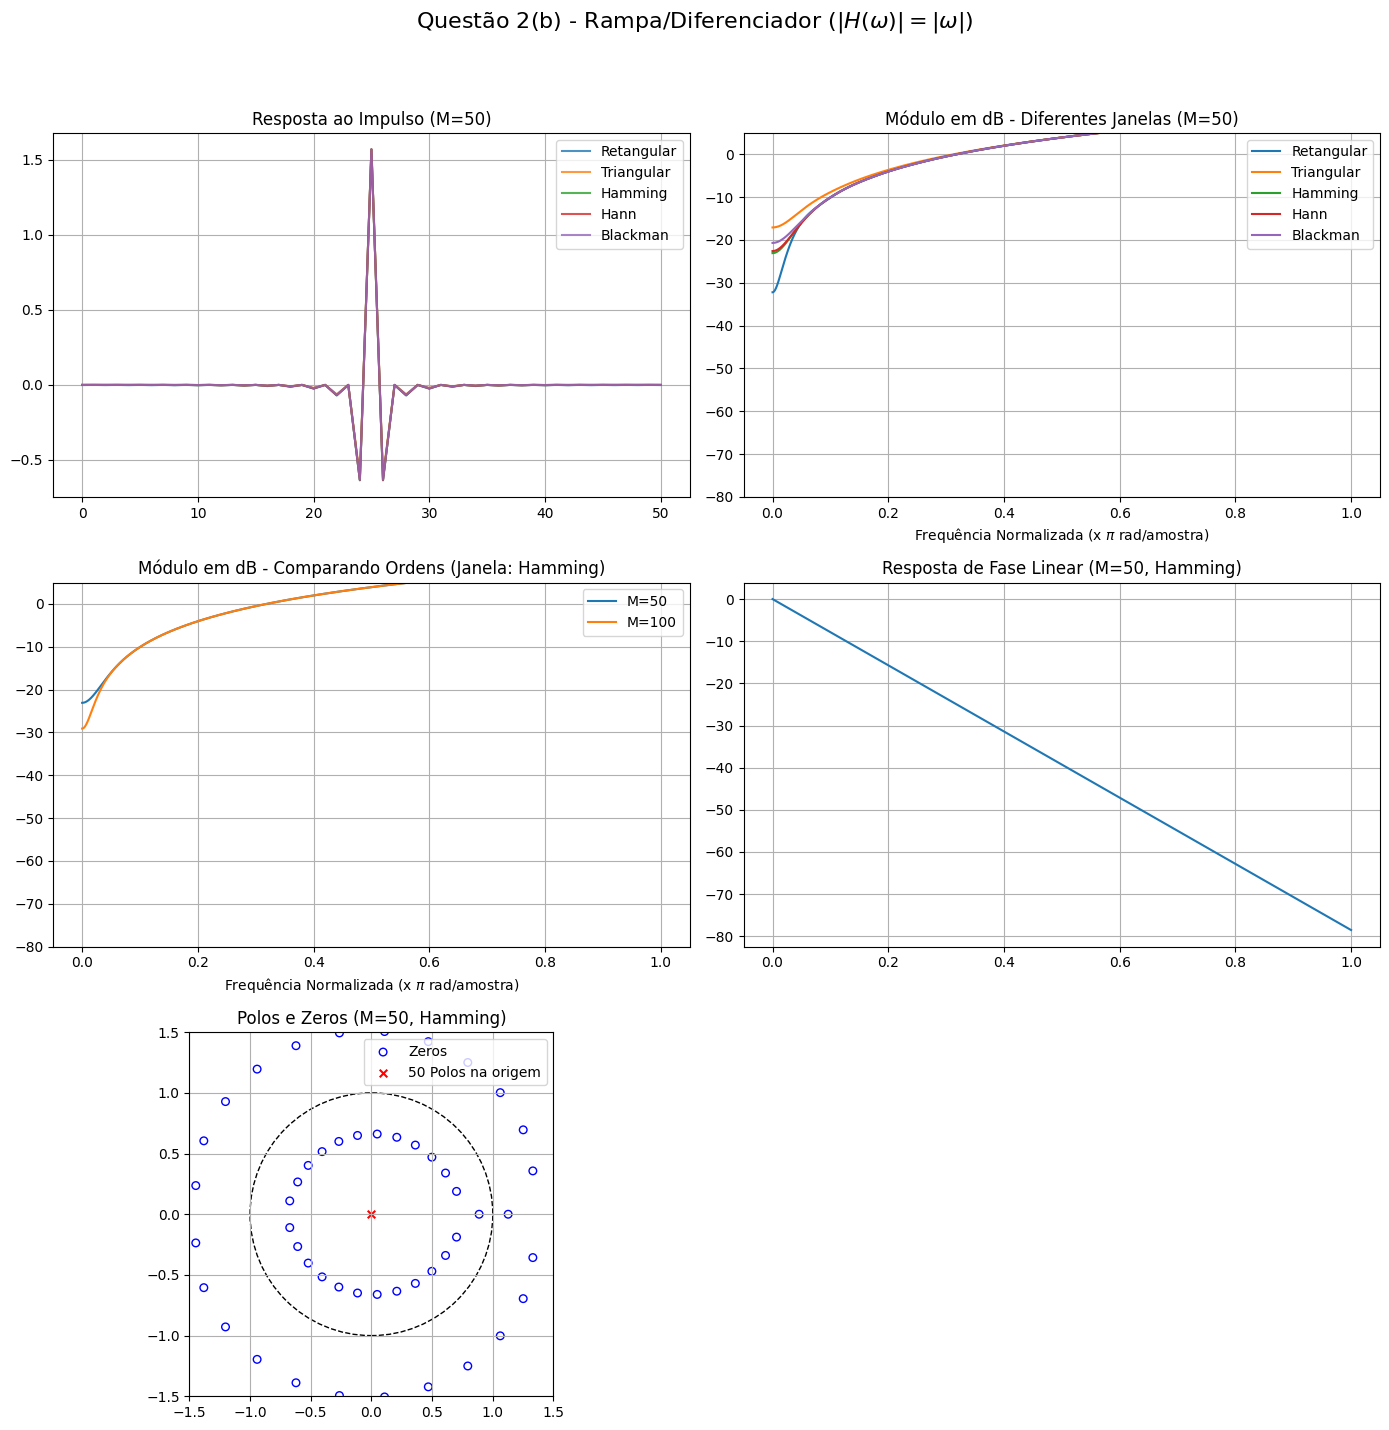

In [14]:
# Resolução 2(b)
def h_ideal_2b(M, window_type):
    n = np.arange(M + 1)
    alpha = M / 2
    h = np.zeros(M + 1)

    for i in range(M + 1):
        idx = i - alpha
        if idx == 0:
            h[i] = np.pi / 2
        else:
            h[i] = ((-1)**idx - 1) / (np.pi * (idx**2))

    return h * get_window_manual(M, window_type)

# Adicionado o 'r' antes das aspas para aceitar o \omega do LaTeX
plot_q2_analysis(h_ideal_2b, r"Questão 2(b) - Rampa/Diferenciador ($|H(\omega)| = |\omega|$)")

2c

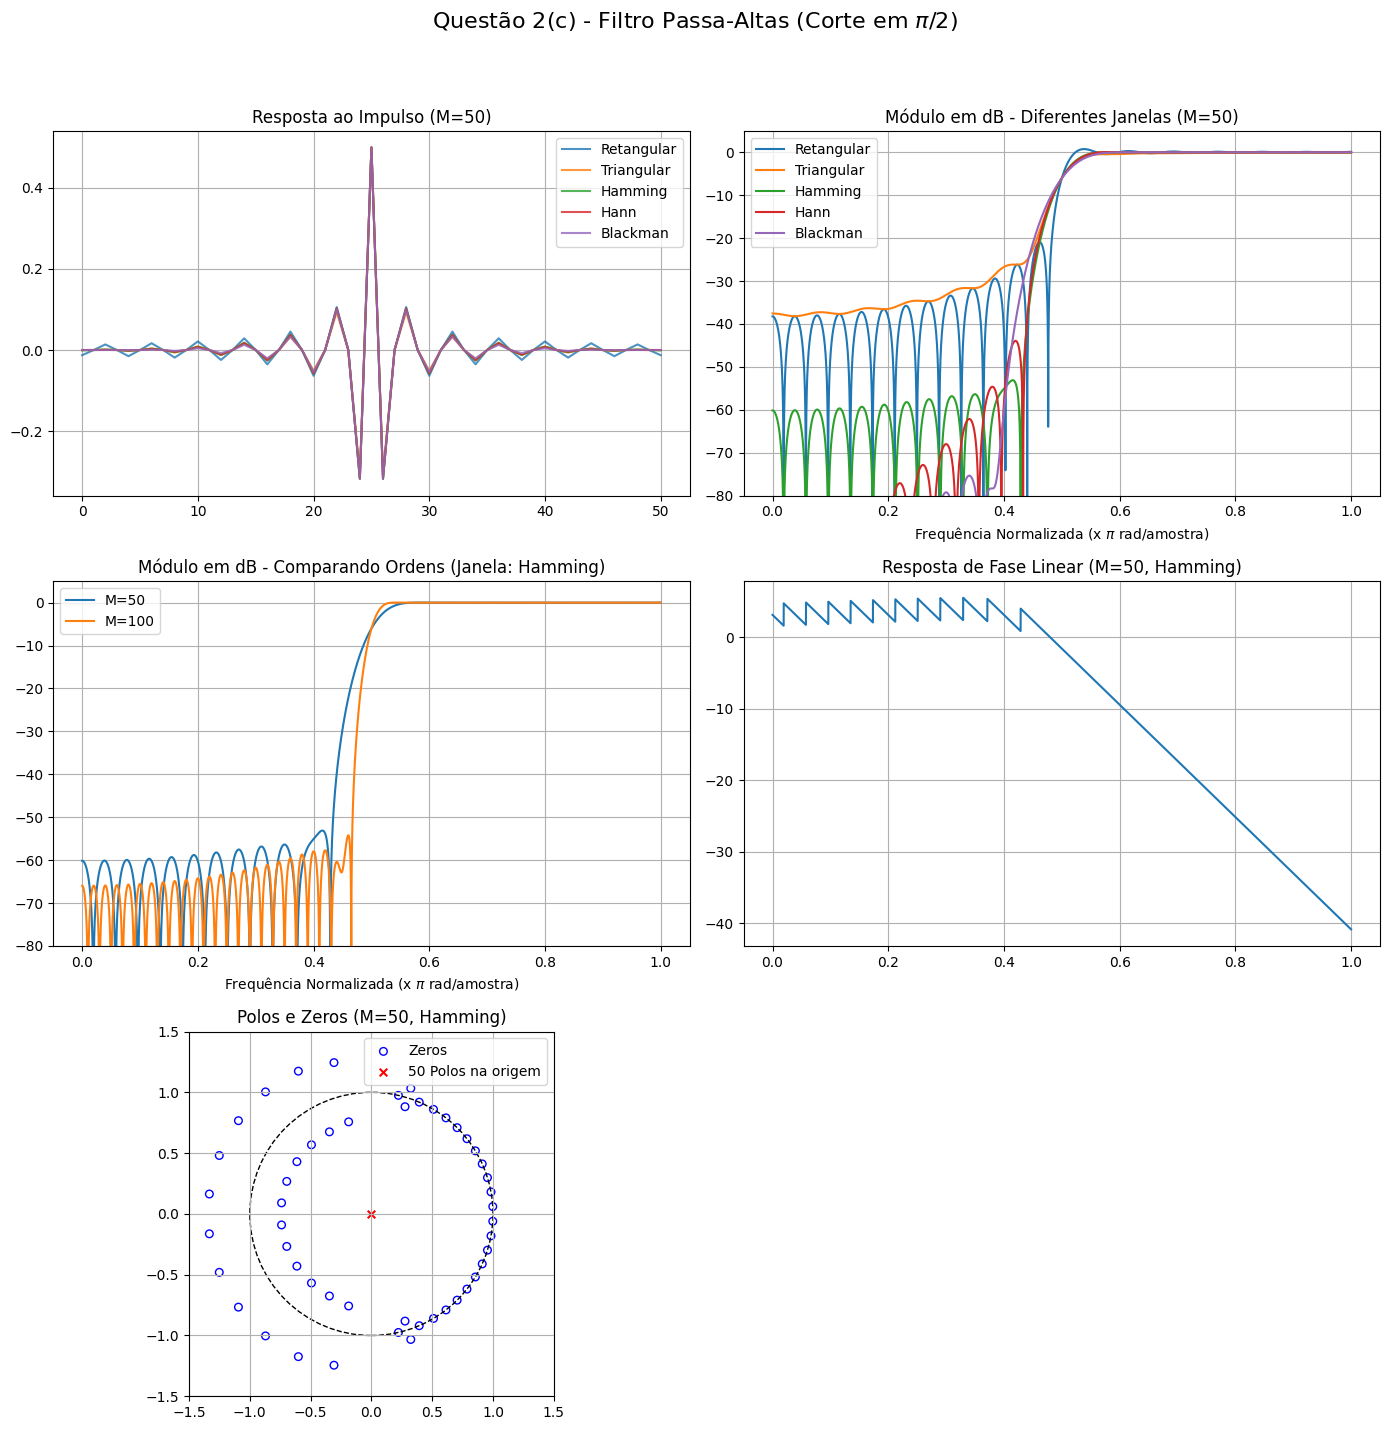

In [15]:
# Resolução 2(c)
def h_ideal_2c(M, window_type):
    n = np.arange(M + 1)
    alpha = M / 2
    eps = 1e-10
    n_safe = np.where(n == alpha, n + eps, n)

    h = -np.sin((np.pi / 2) * (n_safe - alpha)) / (np.pi * (n_safe - alpha))
    if M % 2 == 0:
        h[int(alpha)] = 0.5

    return h * get_window_manual(M, window_type)

# Adicionado o 'r' antes das aspas para aceitar o \pi do LaTeX
plot_q2_analysis(h_ideal_2c, r"Questão 2(c) - Filtro Passa-Altas (Corte em $\pi/2$)")

3a

3b

3c

3d

3e